In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("E:/customer_churn_predictor/dataset/telecom_churn.csv")

In [4]:
df

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1
...,...,...,...,...,...,...,...,...,...,...,...
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0


In [5]:
df.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [6]:
df['Churn'].value_counts(normalize=True)

Churn
0    0.855086
1    0.144914
Name: proportion, dtype: float64

## In dataset - 85.6% not churned, 14.4% churned

In [7]:
import matplotlib.pyplot as plt

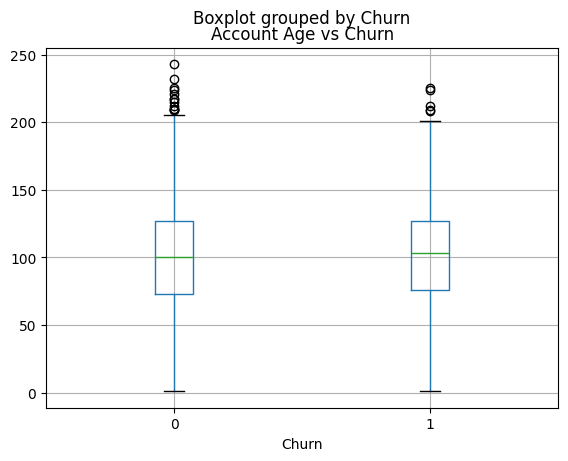

In [8]:
df.boxplot(column='AccountWeeks', by='Churn')
plt.title('Account Age vs Churn')
plt.show()

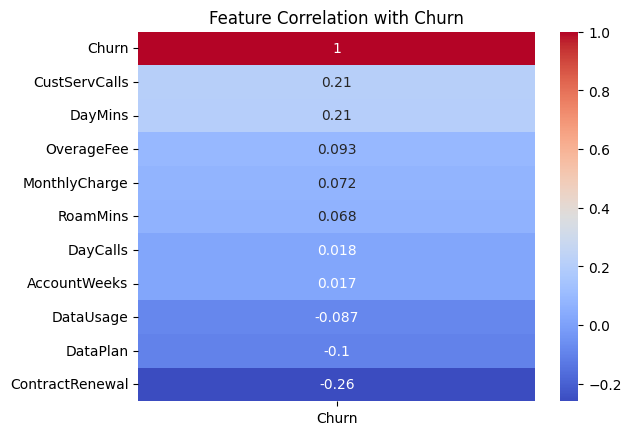

In [9]:
import seaborn as sns

corr = df.corr()
sns.heatmap(corr[['Churn']].sort_values('Churn', ascending=False), 
            annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Churn')
plt.show()

## CustServCalls and DayMins highest factors of churning

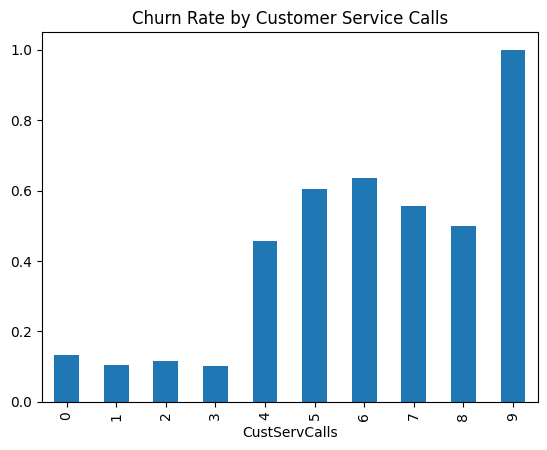

In [10]:
df.groupby('CustServCalls')['Churn'].mean().plot(kind='bar')
plt.title('Churn Rate by Customer Service Calls')
plt.show()

## Avg Churn Rate spikes up when CustServCalls go from 3 to 4

In [11]:
df.groupby('ContractRenewal')['Churn'].mean()

ContractRenewal
0    0.424149
1    0.114950
Name: Churn, dtype: float64

## 42% churn rate for non- ContractRenewals vs 11% for Renewals

In [12]:
pip install lifelines

Note: you may need to restart the kernel to use updated packages.


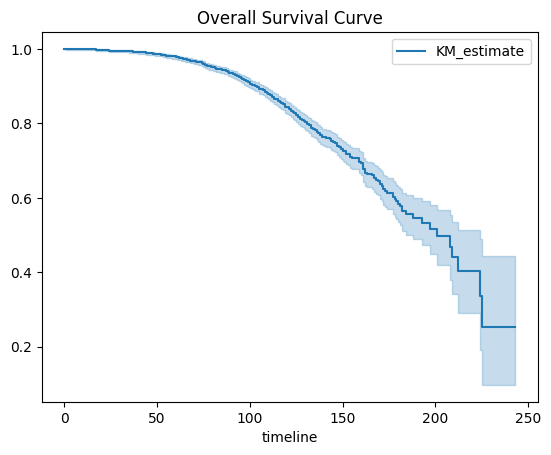

In [13]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df['AccountWeeks'], event_observed=df['Churn'])
kmf.plot_survival_function()
plt.title('Overall Survival Curve')
plt.show()

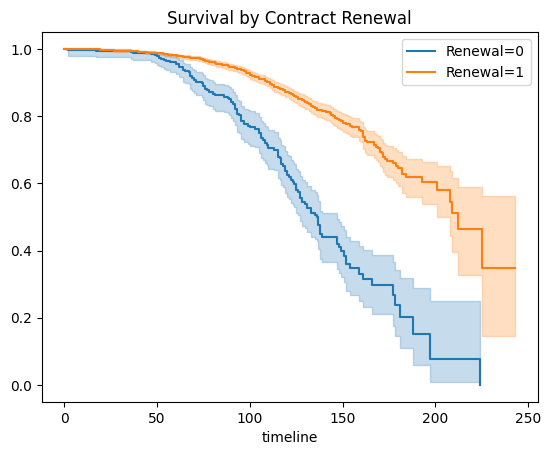

In [14]:
ax = plt.subplot(111)

for renewal, group in df.groupby('ContractRenewal'):
    kmf.fit(group['AccountWeeks'], event_observed=group['Churn'], label=f'Renewal={renewal}')
    kmf.plot_survival_function(ax=ax)

plt.title('Survival by Contract Renewal')
plt.show()

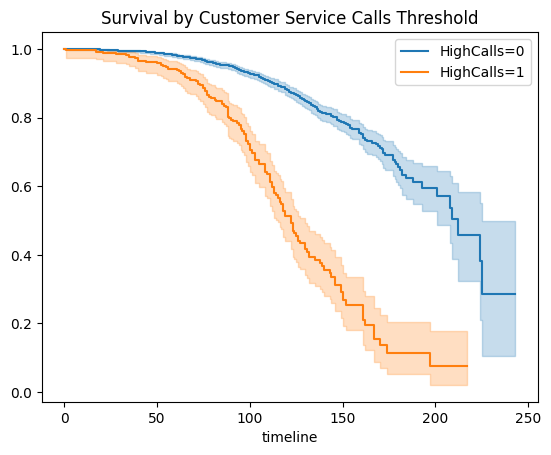

In [15]:
ax = plt.subplot(111)

df['highcalls'] = (df['CustServCalls'] >= 4).astype(int)

for calls, group in df.groupby('highcalls'):
    kmf.fit(group['AccountWeeks'], event_observed=group['Churn'], label=f'HighCalls={calls}')
    kmf.plot_survival_function(ax=ax)

plt.title('Survival by Customer Service Calls Threshold')
plt.show()

In [16]:
from lifelines.statistics import logrank_test

# Test 1: Contract Renewal
renewed = df[df['ContractRenewal'] == 1]
not_renewed = df[df['ContractRenewal'] == 0]

results = logrank_test(renewed['AccountWeeks'], not_renewed['AccountWeeks'],
                       event_observed_A=renewed['Churn'],
                       event_observed_B=not_renewed['Churn'])
print(f"ContractRenewal p-value: {results.p_value}")

# Test 2: CustServCalls threshold
high = df[df['highcalls'] == 1]
low = df[df['highcalls'] == 0]

results2 = logrank_test(high['AccountWeeks'], low['AccountWeeks'],
                        event_observed_A=high['Churn'],
                        event_observed_B=low['Churn'])
print(f"CustServCalls p-value: {results2.p_value}")

ContractRenewal p-value: 2.1737980979372197e-40
CustServCalls p-value: 1.3839187068192127e-66


## Log-rank tests confirm statistically significant survival differences for ContractRenewal (p ≈ 0) and CustServCalls threshold (p ≈ 0), validating both as strong predictors for the Cox PH model.

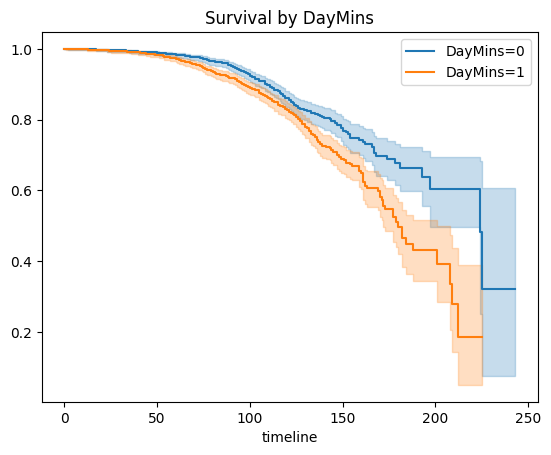

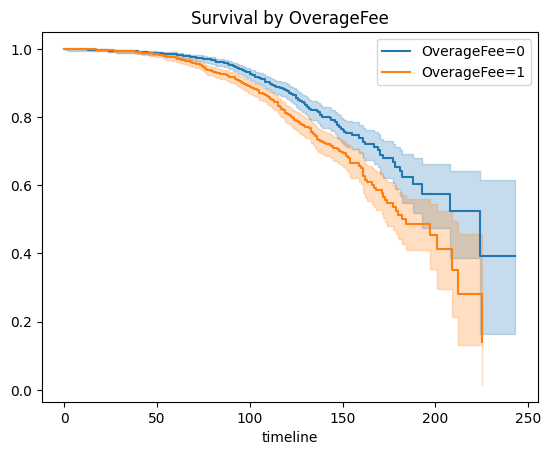

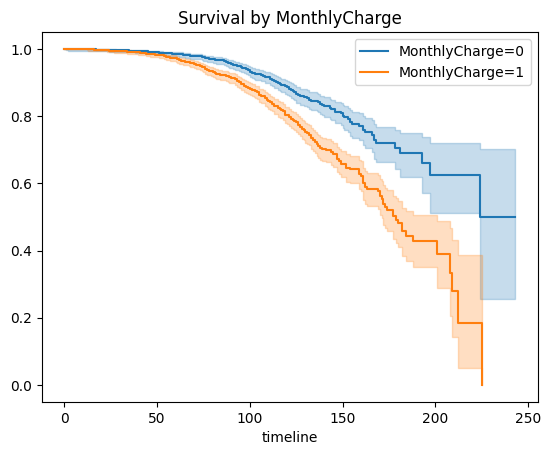

In [17]:
for col in ['DayMins', 'OverageFee', 'MonthlyCharge']:
    df[f'high_{col}'] = (df[col] >= df[col].median()).astype(int)
    
    ax = plt.subplot(111)
    for val, group in df.groupby(f'high_{col}'):
        kmf.fit(group['AccountWeeks'], event_observed=group['Churn'], label=f'{col}={val}')
        kmf.plot_survival_function(ax=ax)
    plt.title(f'Survival by {col}')
    plt.show()

In [18]:
for col in ['DayMins', 'OverageFee', 'MonthlyCharge']:
    df[f'high_{col}'] = (df[col] >= df[col].median()).astype(int)
    high=df[df[f'high_{col}']==1]
    low=df[df[f'high_{col}']==0]

    results = logrank_test(high['AccountWeeks'], low['AccountWeeks'],
                       event_observed_A=high['Churn'],
                       event_observed_B=low['Churn'])
    print(f"{col} p-value: {results.p_value}")

DayMins p-value: 7.179215338412902e-06
OverageFee p-value: 5.863720944466747e-06
MonthlyCharge p-value: 2.588231017923691e-12


## 5 features influence confirmed. Cox model will use:
## ContractRenewal
## CustServCalls
## DayMins
## OverageFee
## MonthlyCharge

In [19]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()

cols = ['AccountWeeks', 'Churn', 'ContractRenewal', 'CustServCalls', 
        'DayMins', 'OverageFee', 'MonthlyCharge']

cph.fit(df[cols], duration_col='AccountWeeks', event_col='Churn')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 3333 total observations, 2850 right-censored observations>
             duration col = 'AccountWeeks'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 3333
number of events observed = 483
   partial log-likelihood = -3228.75
         time fit was run = 2026-05-22 08:50:46 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
ContractRenewal -1.21      0.30      0.10           -1.41           -1.01                0.24                0.37
CustServCalls    0.30      1.36      0.03            0.25            0.36                1.29                1.43
DayMins          0.01      1.01      0.00            0.01            0.02                1.01                1.02
OverageFee       0.12      1.13      0.02            0.08            0.16                1.09                1.17
MonthlyCharge   -0.02      0.98      0.00           -0.03           -0.02                0.97                0.98

                 cmp to      z      p  -log2(p)
covariate                                      
ContractRenewal    0.00 -11.86 <0.005    105.37
CustServCalls      0.00  11.23 <0.005     94.77
DayMins            0.00  11.50 <0.005     99.27
OverageFee         0.00   6.24 <0.005     31.08
MonthlyCharge      0.00  -5.72 <0.005     26.50
---
Concordance = 0.76
Partial AIC = 6467.50
log-likelihood ratio test = 393.88 on 5 df
-log2(p) of ll-ratio test = 273.09

## Cox Model Results:
## ContractRenewal = 0.30 - renewing contract reduces churn risk by 70%.
## CustServCalls = 1.36 - every additional service call increases churn risk by 36%.
## DayMins = 1.01 - every additional minute increases churn risk by 1%.
## OverageFee = 1.13 - every unit increase in overage fee increases churn risk by 13%.
## MonthlyCharge = 0.98 - slight protective effect.

## Thus, for high risk customer:
## No Contract Renewal
## More Customer Service Calls
## More Daily Mins
## More Overage Fee
## Less Monthly Charge

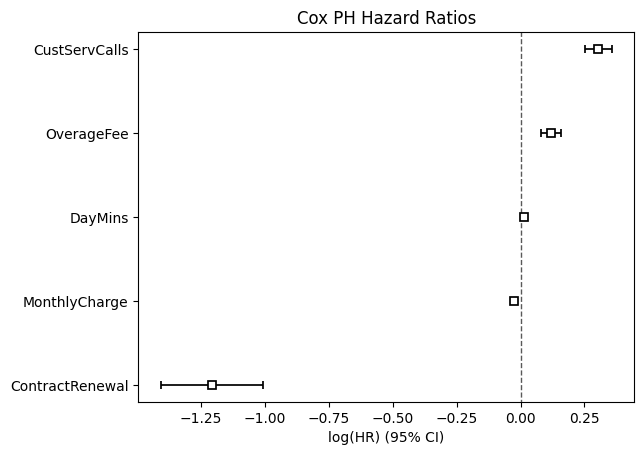

In [20]:
cph.plot()
plt.title('Cox PH Hazard Ratios')
plt.show()

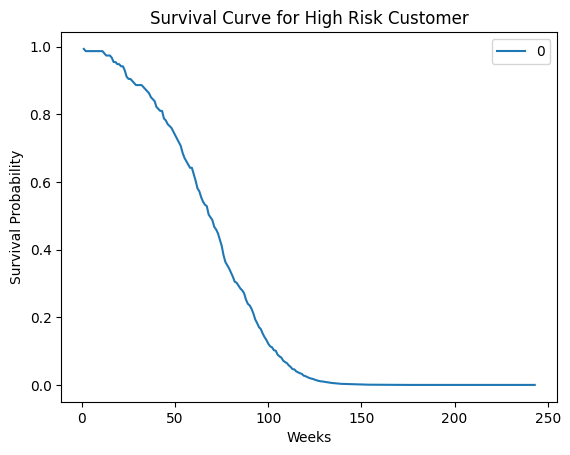

In [21]:
customer = pd.DataFrame({
    'ContractRenewal': [0],
    'CustServCalls': [6],
    'DayMins': [200],
    'OverageFee': [15],
    'MonthlyCharge': [50]
})

survival = cph.predict_survival_function(customer)
survival.plot()
plt.title('Survival Curve for High Risk Customer')
plt.xlabel('Weeks')
plt.ylabel('Survival Probability')
plt.show()

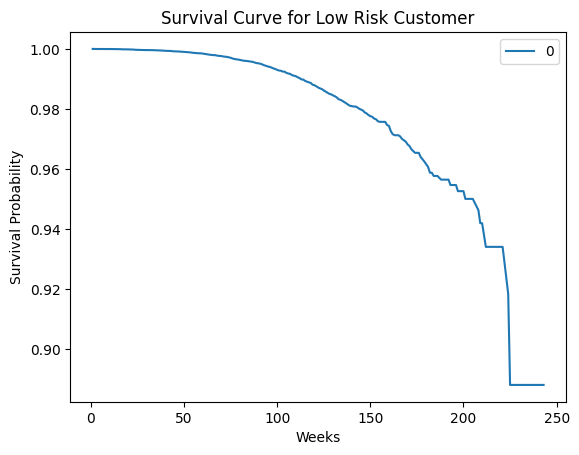

In [22]:
safe_customer = pd.DataFrame({
    'ContractRenewal': [1],
    'CustServCalls': [1],
    'DayMins': [100],
    'OverageFee': [5],
    'MonthlyCharge': [70]
})

survival = cph.predict_survival_function(safe_customer)
survival.plot()
plt.title('Survival Curve for Low Risk Customer')
plt.xlabel('Weeks')
plt.ylabel('Survival Probability')
plt.show()

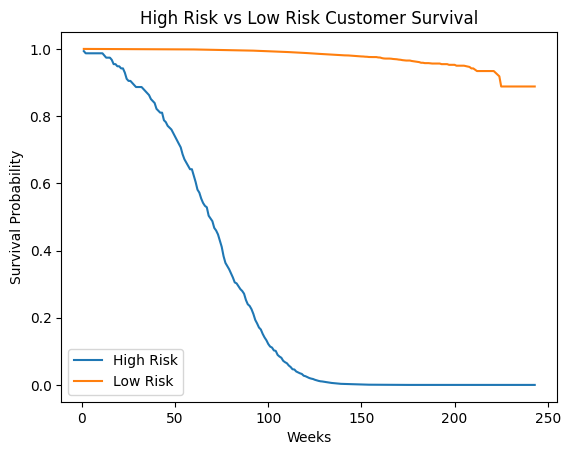

In [23]:
ax = plt.subplot(111)

cph.predict_survival_function(customer).rename(columns={0: 'High Risk'}).plot(ax=ax)
cph.predict_survival_function(safe_customer).rename(columns={0: 'Low Risk'}).plot(ax=ax)

plt.title('High Risk vs Low Risk Customer Survival')
plt.xlabel('Weeks')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

In [24]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


c:\Users\Tanish\anaconda3\envs\Tanish\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ExactExplainer explainer: 3334it [00:16, 109.40it/s]                          


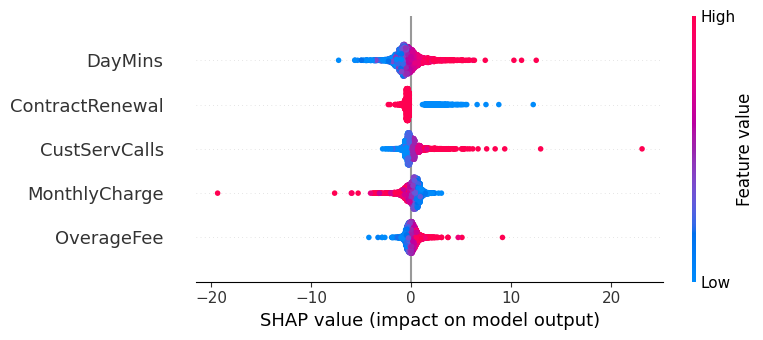

In [25]:
import shap

explainer = shap.Explainer(
    cph.predict_partial_hazard, 
    df[['ContractRenewal', 'CustServCalls', 'DayMins', 'OverageFee', 'MonthlyCharge']]
)

shap_values = explainer(
    df[['ContractRenewal', 'CustServCalls', 'DayMins', 'OverageFee', 'MonthlyCharge']]
)

shap.summary_plot(
    shap_values, 
    df[['ContractRenewal', 'CustServCalls', 'DayMins', 'OverageFee', 'MonthlyCharge']]
)

## DayMins — red dots (high DayMins) push right = increases risk. Blue dots cluster near 0. Confirms what you found.
## ContractRenewal — blue dots (no renewal = low value = 0) push far right = massive churn risk increase. Red dots (renewed = 1) push left = protective. This is your strongest feature — see how far those blue dots spread right.
## CustServCalls — red dots (high calls) push right = increases risk. Clean pattern.
## MonthlyCharge — red dots push left = high charge is protective. Confirms your earlier finding.
## OverageFee — red dots push slightly right = increases risk but weak effect.

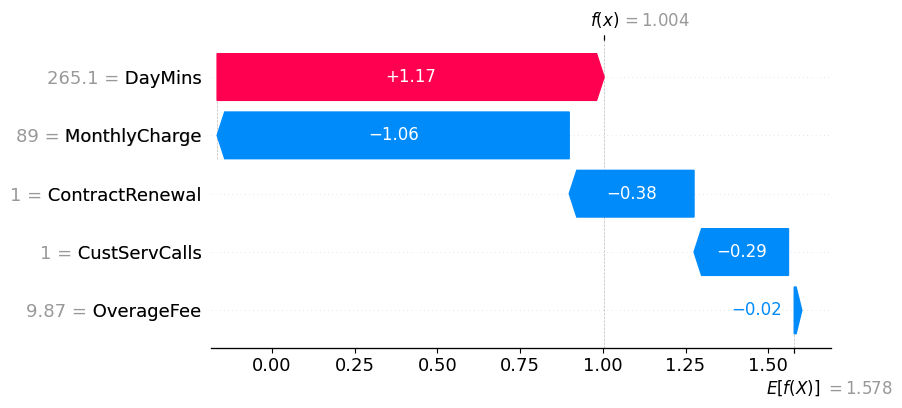

In [26]:
shap.plots.waterfall(shap_values[0])

In [27]:
import pickle

with open('../model/cox_model.pkl', 'wb') as f:
    pickle.dump(cph, f)